# Risk Rectification in Heteroscedastic Regression — GAM + TabICL

Python implementation of the heteroscedastic experiment. Three methods are compared:

- **M1) Standard CRC**: one global value of $\lambda$ calibrated by CRC.
- **M2) Oracle Rectified CRC**: $R(\lambda \mid x)$ is computed from the Gaussian DGP.
- **M3) Rectified Route 2**: $R(\lambda \mid x)$ is estimated by **TabICL** on an augmented context dataset $((X,\lambda), Z)$.

DGP:

$$
X \sim \mathrm{Unif}(-2,2),
\qquad
\mu(x)=\sin(\pi x/2),
\qquad
\sigma(x)=0.2+0.6|x|,
$$

and

$$
Y\mid X=x \sim N\{\mu(x),\sigma^2(x)\}.
$$

Prediction bands are of the form

$$
C_\lambda(x)=\left[\widehat\mu(x)-\lambda(x),\widehat\mu(x)+\lambda(x)\right],
$$

where $\widehat\mu(x)$ is estimated by a univariate GAM.

The calibration loss is now the **bounded absolute excess loss**

$$
L_\lambda(x,y)
=
\min\left\{1,
\frac{(|y-\widehat\mu(x)|-\lambda(x))_+}{B_{\mathrm{excess}}}
\right\}.
$$

The true $\sigma(x)$ is **not used inside the loss**. It is used only to generate the data, to compute the oracle risk implied by the known Gaussian DGP, and to define diagnostic difficulty bins.

The simulation uses four independent samples in each Monte Carlo replication:

- a **training sample** to fit $\widehat\mu(x)$;
- a **context sample** to construct the augmented TabICL risk-estimation dataset;
- a **calibration sample** to calibrate the CRC/rectified parameters;
- a **test sample** used only for evaluation.

TabICL is used only to estimate the conditional risk surface $(x,\lambda)\mapsto R(\lambda\mid X=x)$; it is not used to predict $Y$ directly.

**GPU note**: this notebook is intended for Colab with GPU enabled. Runtime $\to$ Change runtime type $\to$ GPU.


In [4]:
# Instalações
!pip install -q tabicl pygam scikit-learn pandas matplotlib seaborn

import torch
print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA disponível: True
GPU: Tesla T4


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import KFold
from pygam import LinearGAM, s
from tabicl import TabICLRegressor
from dataclasses import dataclass
from typing import Callable
import time

rng_global = np.random.default_rng(1234)
sns.set_theme(style="whitegrid", context="notebook")


## 1. DGP

In [6]:
def mu_true(x):
    return np.sin(np.pi * x / 2)

def sigma_true(x):
    return 0.2 + 0.6 * np.abs(x)

def gerar_dataset(n, rng):
    X = rng.uniform(-2, 2, size=n)
    mu = mu_true(X)
    sg = sigma_true(X)
    Y = mu + sg * rng.standard_normal(n)
    return pd.DataFrame({"X": X, "Y": Y, "mu_true": mu, "sigma_true": sg})


## 2. Base regression model $\widehat\mu(x)$

The base regression model is a univariate GAM fitted only on the training sample.
The context sample is kept separate and is used later to construct the TabICL context dataset for risk estimation.


In [7]:
def fit_mu(D: pd.DataFrame, n_splines=20, lam=0.6):
    """Fit a univariate GAM for E[Y | X]."""
    gam = LinearGAM(s(0, n_splines=n_splines), lam=lam)
    gam.fit(D[["X"]].values, D["Y"].values)
    return gam


def predict_mu(gam, x):
    """Predict the conditional mean using a fitted GAM."""
    x = np.atleast_1d(x).reshape(-1, 1)
    return gam.predict(x)


## 3. Oracle $R(\lambda \mid x)$ — forma fechada

Sob $Y \mid x \sim \mathcal{N}(\mu(x), \sigma(x)^2)$ e família centrada em $\hat\mu(x)$ com viés $b(x) = \hat\mu(x) - \mu(x)$:

$$R(\lambda \mid x) = \sigma\,[\phi(\lambda_+/\sigma) + \phi(\lambda_-/\sigma)] - \lambda\,[\Phi(-\lambda_+/\sigma) + \Phi(-\lambda_-/\sigma)] + b\,[\Phi(-\lambda_+/\sigma) - \Phi(-\lambda_-/\sigma)]$$

com $\lambda_\pm = \lambda \mp b$.

In [8]:

B_LOSS = 1.0          # upper bound of the loss used by CRC
EXCESS_SCALE = 1.5    # B_excess in min(1, excess / B_excess)

def excess_loss(residual, lam):
    """Unbounded excess loss: max(0, residual - lambda)."""
    return np.maximum(0.0, residual - lam)

def bounded_excess_loss(residual, lam, excess_scale=EXCESS_SCALE):
    """
    Bounded absolute excess loss:
        min(1, max(0, residual - lambda) / B_excess).

    This loss does not use sigma(x). The true sigma(x) remains only in the DGP,
    in the oracle Gaussian risk calculation, and in diagnostic difficulty bins.
    """
    return np.minimum(
        1.0,
        np.maximum(0.0, residual - lam) / excess_scale
    )

def oracle_R_dist_unbounded(lam, sigma, bias=0.0):
    """
    E[max(0, |W| - lam)] with W = Y - mu_hat ~ N(-bias, sigma^2),
    where bias = mu_hat(x) - mu_true(x).
    """
    lam_p = lam - bias
    lam_m = lam + bias
    z_p = lam_p / sigma
    z_m = lam_m / sigma

    return (
        sigma * (stats.norm.pdf(z_p) + stats.norm.pdf(z_m))
        - lam * (stats.norm.cdf(-z_p) + stats.norm.cdf(-z_m))
        + bias * (stats.norm.cdf(-z_p) - stats.norm.cdf(-z_m))
    )

def oracle_R_dist_bounded(lam, sigma, bias=0.0, excess_scale=EXCESS_SCALE):
    """
    Oracle conditional risk for the bounded absolute excess loss:

        E[min(1, (|W|-lam)_+ / B_excess)].

    Identity:
        min(1, (u-lam)_+ / B) =
        [(u-lam)_+ - (u-lam-B)_+] / B.
    """
    return (
        oracle_R_dist_unbounded(lam, sigma, bias)
        - oracle_R_dist_unbounded(lam + excess_scale, sigma, bias)
    ) / excess_scale

def oracle_R_matriz(x_vec, lambda_grid, mu_hat_fn):
    """
    Matrix n x L with R(lambda_j | x_i) under the known Gaussian DGP.

    The loss is the bounded absolute excess loss, so sigma_true(x) is NOT used
    to normalize the loss. It enters only because the conditional distribution
    of Y|X=x has standard deviation sigma_true(x).
    """
    sg = sigma_true(x_vec)
    bias = mu_hat_fn(x_vec) - mu_true(x_vec)

    out = np.empty((len(x_vec), len(lambda_grid)))
    for j, lam in enumerate(lambda_grid):
        out[:, j] = oracle_R_dist_bounded(lam, sg, bias)

    return np.clip(out, 0.0, B_LOSS)


## 4. Rectified Route 2 — TabICL on an augmented context dataset

The TabICL context sample is constructed from an independent context dataset, not from the sample used to fit the base regression model.

For each context observation $(X_i,Y_i)$, compute

$$
r_i = |Y_i-\widehat\mu(X_i)|,
$$

where $\widehat\mu$ was fitted on the training sample. Then draw $K_{\mathrm{aug}}$ candidate values $\lambda_{ik}\sim \mathrm{Unif}(0,\lambda_{\max})$ and define

$$
Z_{ik}=
\min\left\{1,
\frac{(r_i-\lambda_{ik})_+}{B_{\mathrm{excess}}}
\right\}.
$$

This gives the augmented context dataset

$$
\mathcal D_{\mathrm{ctx}}=
\{((X_i,\lambda_{ik}),Z_{ik}) : i\in D_{\mathrm{ctx}},\ k=1,\ldots,K_{\mathrm{aug}}\}.
$$

TabICL is then used to estimate

$$
(x,\lambda)\mapsto R(\lambda\mid X=x).
$$

Monotonicity in $\lambda$ is imposed afterwards through reverse isotonic regression.


In [9]:

def build_augmented_context_dataset(D_context, mu_context, K_aug=15, lambda_max=4.0, rng=None):
    """
    Build the augmented context dataset for TabICL.

    Inputs:
        D_context: independent context sample with columns X and Y.
        mu_context: predictions mu_hat(X) from the base model fitted on D_train.

    Output:
        X_aug: matrix with columns (X, lambda).
        Z_aug: bounded absolute excess loss.
    """
    if rng is None:
        rng = np.random.default_rng()

    residual_context = np.abs(D_context["Y"].values - mu_context)
    n_context = len(D_context)

    X_rep = np.repeat(D_context["X"].values, K_aug)
    residual_rep = np.repeat(residual_context, K_aug)
    lambda_rep = rng.uniform(0, lambda_max, size=n_context * K_aug)

    Z_rep = bounded_excess_loss(residual_rep, lambda_rep)
    X_aug = np.column_stack([X_rep, lambda_rep])

    return X_aug, Z_rep


def fit_risk_surface_tabicl(D_context, mu_context, K_aug=15, lambda_max=4.0,
                            device="cuda", rng=None):
    """Fit TabICL to estimate the conditional risk surface."""
    X_aug, Z_aug = build_augmented_context_dataset(
        D_context,
        mu_context,
        K_aug=K_aug,
        lambda_max=lambda_max,
        rng=rng
    )
    reg = TabICLRegressor(device=device, kv_cache=True, random_state=42)
    reg.fit(X_aug, Z_aug)
    return reg


def estimate_R_route2(reg_surface, x_vec, lambda_grid):
    """
    Estimate R(lambda | x) on a grid of lambda values using TabICL.

    Returns an n x L matrix and enforces nonincreasing risk in lambda
    by reverse isotonic regression for each queried x.
    """
    x_vec = np.asarray(x_vec)
    n = len(x_vec)
    L = len(lambda_grid)
    R_hat = np.empty((n, L))

    for j, lam in enumerate(lambda_grid):
        X_query = np.column_stack([x_vec, np.full(n, lam)])
        R_hat[:, j] = reg_surface.predict(X_query)

    R_hat = np.clip(R_hat, 0.0, B_LOSS)

    for i in range(n):
        iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
        neg_R_iso = iso.fit_transform(lambda_grid, -R_hat[i])
        R_hat[i] = np.clip(-neg_R_iso, 0.0, B_LOSS)

    return R_hat


## 5. Inversão de $R$ e calibração CRC

In [10]:
def inverter_R(R_row, lambda_grid, a):
    # inf { lambda in grid : R(lambda) <= a }
    mask = R_row <= a
    if not mask.any():
        return float(lambda_grid[-1])
    return float(lambda_grid[np.argmax(mask)])

def calibrar_crc(losses_cal, lambda_grid, alpha, B=B_LOSS):
    # CRC padrao: menor lambda com R_upper(lambda) <= alpha
    n = losses_cal.shape[0]
    R_cal = losses_cal.mean(axis=0)
    R_upper = (n * R_cal + B) / (n + 1)
    mask = R_upper <= alpha
    if not mask.any():
        return float(lambda_grid[-1])
    return float(lambda_grid[np.argmax(mask)])

def calibrar_crc_rectified(losses_rect, a_grid, alpha, B=B_LOSS):
    # CRC rectified: maior a com R_upper(a) <= alpha
    n = losses_rect.shape[0]
    R_cal = losses_rect.mean(axis=0)
    R_upper = (n * R_cal + B) / (n + 1)
    mask = R_upper <= alpha
    if not mask.any():
        return float(a_grid[0])
    return float(a_grid[np.where(mask)[0].max()])


## 6. One-replication pipeline

Each Monte Carlo replication uses four independent samples:

- `D_train`: fits the GAM mean model;
- `D_context`: builds the TabICL augmented context dataset for risk estimation;
- `cal`: calibrates the CRC and rectified procedures;
- `test`: evaluates risk, conditional risk diagnostics, and band width.


In [11]:
@dataclass
class ResultadoRodada:
    df_metricas: pd.DataFrame
    a_hat_oracle: float
    a_hat_r2: float
    lambda_fixo: float
    bandas: dict


def rodar_uma_rodada(n_train, n_context, n_cal, n_test, alpha, L=41, K_aug=15,
                     B=B_LOSS, device="cuda", verbose=False, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    lambda_grid = np.linspace(0, 4, L)
    a_grid = np.linspace(0.001, 1, 40)

    # Independent samples for the different stages.
    D_train = gerar_dataset(n_train, rng)
    D_context = gerar_dataset(n_context, rng)
    cal = gerar_dataset(n_cal, rng)
    test = gerar_dataset(n_test, rng)

    # Base model: fitted only on D_train.
    if verbose:
        print("  fitting base mean model on training sample")
    gam_mu = fit_mu(D_train)

    # Predictions on context, calibration and test samples.
    mu_context = predict_mu(gam_mu, D_context["X"].values)
    mu_cal = predict_mu(gam_mu, cal["X"].values)
    mu_test = predict_mu(gam_mu, test["X"].values)

    res_cal = np.abs(cal["Y"].values - mu_cal)
    res_test = np.abs(test["Y"].values - mu_test)

    # ====== M1) Standard CRC ======
    if verbose:
        print("  M1 Standard CRC")
    losses_cal_fixo = bounded_excess_loss(
        res_cal[:, None],
        lambda_grid[None, :]
    )
    lambda_fixo = calibrar_crc(losses_cal_fixo, lambda_grid, alpha, B=B)
    loss_fixo = bounded_excess_loss(res_test, lambda_fixo)
    width_fixo = np.full(n_test, 2 * lambda_fixo)

    # ----- helper for rectification -----
    def rectificar(R_cal_mat, R_test_mat):
        losses_cal_rect = np.empty((n_cal, len(a_grid)))

        for j, a in enumerate(a_grid):
            for i in range(n_cal):
                lam_i = inverter_R(R_cal_mat[i], lambda_grid, a)
                losses_cal_rect[i, j] = bounded_excess_loss(
                    res_cal[i],
                    lam_i
                )

        a_hat = calibrar_crc_rectified(losses_cal_rect, a_grid, alpha, B=B)

        loss_t = np.empty(n_test)
        width_t = np.empty(n_test)
        lambda_t = np.empty(n_test)

        for i in range(n_test):
            lam_i = inverter_R(R_test_mat[i], lambda_grid, a_hat)
            lambda_t[i] = lam_i
            loss_t[i] = bounded_excess_loss(res_test[i], lam_i)
            width_t[i] = 2 * lam_i

        return a_hat, loss_t, width_t, lambda_t

    # ====== M2) Oracle Rectified CRC ======
    if verbose:
        print("  M2 Oracle Rectified CRC")
    R_or_cal = oracle_R_matriz(
        cal["X"].values,
        lambda_grid,
        lambda x: predict_mu(gam_mu, x)
    )
    R_or_test = oracle_R_matriz(
        test["X"].values,
        lambda_grid,
        lambda x: predict_mu(gam_mu, x)
    )
    a_hat_or, loss_or, width_or, lambda_or = rectificar(R_or_cal, R_or_test)

    # ====== M3) Rectified Route 2 via TabICL ======
    if verbose:
        print("  M3 Rectified Route 2: fitting TabICL risk surface")
    t0 = time.time()
    reg_surface = fit_risk_surface_tabicl(
        D_context,
        mu_context,
        K_aug=K_aug,
        lambda_max=4.0,
        device=device,
        rng=rng
    )
    if verbose:
        print(f"     fit time: {time.time() - t0:.1f}s")

    t0 = time.time()
    R_r2_cal = estimate_R_route2(reg_surface, cal["X"].values, lambda_grid)
    if verbose:
        print(f"     calibration prediction time: {time.time() - t0:.1f}s")

    t0 = time.time()
    R_r2_test = estimate_R_route2(reg_surface, test["X"].values, lambda_grid)
    if verbose:
        print(f"     test prediction time: {time.time() - t0:.1f}s")

    a_hat_r2, loss_r2, width_r2, lambda_r2 = rectificar(R_r2_cal, R_r2_test)

    # ====== Metrics by difficulty bin ======
    G = 5
    bin_edges = np.quantile(test["sigma_true"].values, np.linspace(0, 1, G + 1))
    bin_edges[0] -= 1e-9
    bins = np.searchsorted(bin_edges[1:-1], test["sigma_true"].values, side="right")

    def metricas(loss, width, lambda_vec, metodo):
        R_bins = np.array([
            loss[bins == g].mean() if (bins == g).any() else np.nan
            for g in range(G)
        ])
        return {
            "metodo": metodo,
            "R_test": loss.mean(),
            "cobertura_emp": (loss == 0).mean(),
            "max_bin_risk": np.nanmax(R_bins),
            "media_excesso_bin": np.nanmean(np.maximum(R_bins - alpha, 0)),
            "width_medio": width.mean(),
            "lambda_sd": lambda_vec.std(ddof=1) if len(lambda_vec) > 1 else 0.0,
            "R_bins": R_bins.tolist(),
        }

    df_metricas = pd.DataFrame([
        metricas(loss_fixo, width_fixo, np.full(n_test, lambda_fixo), "crc-padrao"),
        metricas(loss_or, width_or, lambda_or, "oracle-rect"),
        metricas(loss_r2, width_r2, lambda_r2, "rect-route2"),
    ])

    bandas = {
        "crc-padrao": dict(
            lower=mu_test - lambda_fixo,
            upper=mu_test + lambda_fixo,
            X=test["X"].values,
            Y=test["Y"].values,
        ),
        "oracle-rect": dict(
            lower=mu_test - lambda_or,
            upper=mu_test + lambda_or,
            X=test["X"].values,
            Y=test["Y"].values,
        ),
        "rect-route2": dict(
            lower=mu_test - lambda_r2,
            upper=mu_test + lambda_r2,
            X=test["X"].values,
            Y=test["Y"].values,
        ),
    }

    return ResultadoRodada(df_metricas, a_hat_or, a_hat_r2, lambda_fixo, bandas)


## 7. Run the Monte Carlo experiment

The configuration below is kept moderate for Colab GPU. Increase `n_rodadas` for the final simulation study.


In [12]:
config = dict(
    n_train=500,
    n_context=500,
    n_cal=300,
    n_test=1000,
    alpha=0.10,
    B=B_LOSS,
    L=41,
    K_aug=15,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

n_rodadas = 20

todos_resultados = []
bandas_r1 = None

for r in range(n_rodadas):
    print(f"\n--- Monte Carlo replication {r + 1}/{n_rodadas} ---")
    t_ini = time.time()
    rng_r = np.random.default_rng(2026 + r + 1)

    out = rodar_uma_rodada(**config, verbose=(r == 0), rng=rng_r)

    print(
        f"  time: {time.time() - t_ini:.1f}s | "
        f"lambda_standard={out.lambda_fixo:.3f} | "
        f"a_hat_oracle={out.a_hat_oracle:.3f} | "
        f"a_hat_route2={out.a_hat_r2:.3f}"
    )

    df_r = out.df_metricas.copy()
    df_r["rodada"] = r + 1
    todos_resultados.append(df_r)

    if r == 0:
        bandas_r1 = out.bandas



--- Monte Carlo replication 1/20 ---
  fitting base mean model on training sample
  M1 Standard CRC
  M2 Oracle Rectified CRC
  M3 Rectified Route 2: fitting TabICL risk surface


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Checkpoint 'tabicl-regressor-v2-20260212.ckpt' not cached.



tabicl-regressor-v2-20260212.ckpt:   0%|          | 0.00/114M [00:00<?, ?B/s]

     fit time: 15.4s
     calibration prediction time: 3.2s
     test prediction time: 5.7s
  time: 24.7s | lambda_standard=0.900 | a_hat_oracle=0.103 | a_hat_route2=0.078

--- Monte Carlo replication 2/20 ---
  time: 10.7s | lambda_standard=0.900 | a_hat_oracle=0.103 | a_hat_route2=0.078

--- Monte Carlo replication 3/20 ---
  time: 10.9s | lambda_standard=1.000 | a_hat_oracle=0.078 | a_hat_route2=0.052

--- Monte Carlo replication 4/20 ---
  time: 10.8s | lambda_standard=1.000 | a_hat_oracle=0.103 | a_hat_route2=0.103

--- Monte Carlo replication 5/20 ---
  time: 10.9s | lambda_standard=1.000 | a_hat_oracle=0.078 | a_hat_route2=0.078

--- Monte Carlo replication 6/20 ---
  time: 10.8s | lambda_standard=0.900 | a_hat_oracle=0.103 | a_hat_route2=0.078

--- Monte Carlo replication 7/20 ---
  time: 10.9s | lambda_standard=1.100 | a_hat_oracle=0.078 | a_hat_route2=0.078

--- Monte Carlo replication 8/20 ---
  time: 10.9s | lambda_standard=0.800 | a_hat_oracle=0.103 | a_hat_route2=0.078

-

In [189]:
# Resumo agregado
todos = pd.concat(todos_resultados, ignore_index=True)

resumo = (todos
    .drop(columns=["R_bins"])
    .groupby("metodo")
    .agg(["mean", "std"])
    .round(4))
print("\n========== RESUMO ==========")
print(resumo)



========== RESUMO ==========
             R_test         cobertura_emp         max_bin_risk          \
               mean     std          mean     std         mean     std   
metodo                                                                   
crc-padrao   0.0892  0.0160        0.7564  0.0355       0.2113  0.0408   
oracle-rect  0.0884  0.0147        0.6377  0.0477       0.1080  0.0174   
rect-route2  0.0845  0.0113        0.6649  0.0411       0.1148  0.0168   

            media_excesso_bin         width_medio         lambda_sd          \
                         mean     std        mean     std      mean     std   
metodo                                                                        
crc-padrao             0.0315  0.0127      1.8900  0.1774    0.0000  0.0000   
oracle-rect            0.0033  0.0052      1.7058  0.1300    0.5025  0.0265   
rect-route2            0.0043  0.0039      1.8050  0.1031    0.5648  0.0586   

            rodada          
              mean   

## 8. Visualizations


/tmp/ipykernel_465/4176192161.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_465/4176192161.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([method_labels[m] for m in method_order], rotation=20)
/tmp/ipykernel_465/4176192161.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_465/4176192161.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([method_labels[m] for m in method_order], rotation=20)
/tmp/ipykernel_465/4176192161.py:23: FutureW

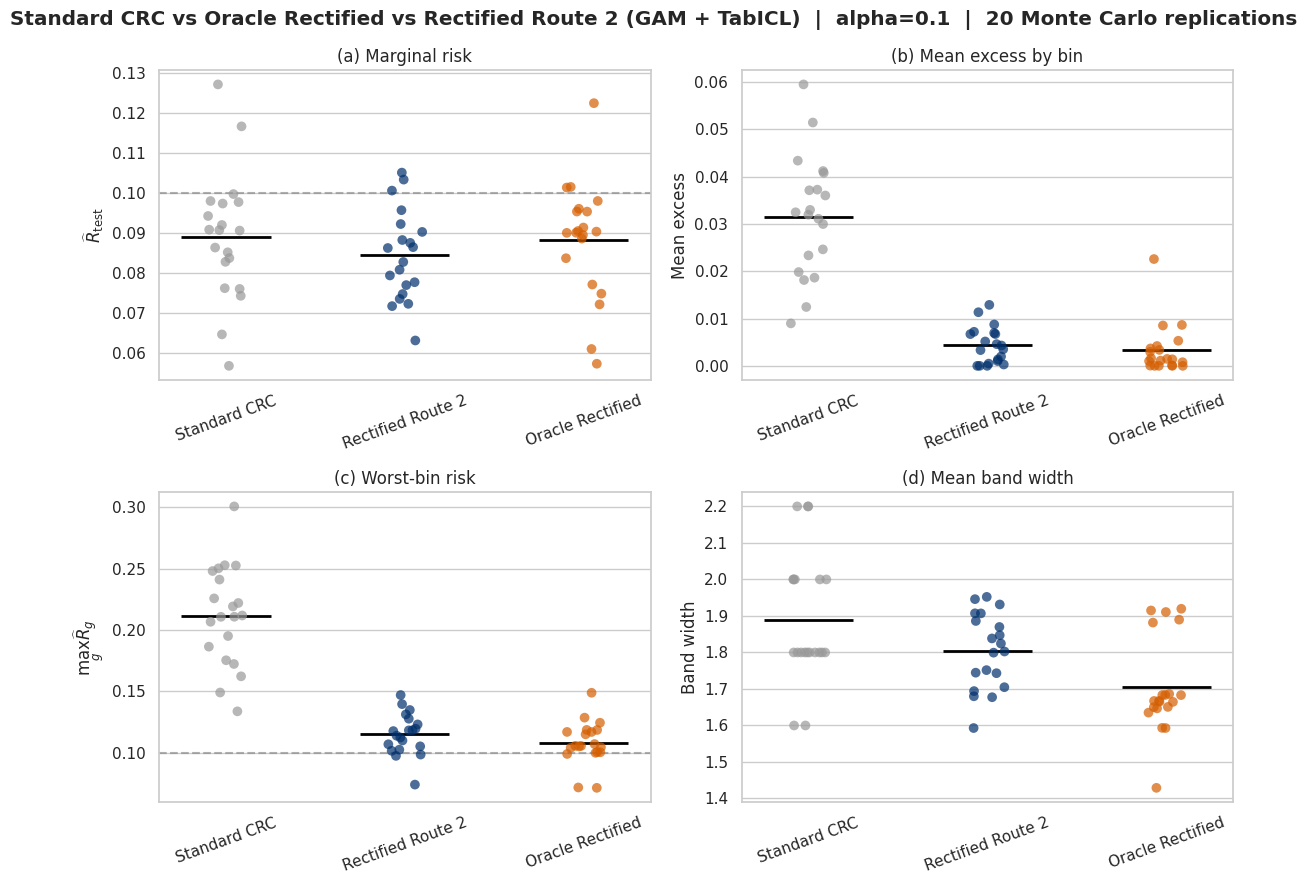

In [190]:
# ============================================================
# Global Monte Carlo summary plots
# All plot labels are in English
# ============================================================

method_order = ["crc-padrao", "rect-route2", "oracle-rect"]
method_labels = {
    "crc-padrao": "Standard CRC",
    "rect-route2": "Rectified Route 2",
    "oracle-rect": "Oracle Rectified"
}
method_colors = {
    "crc-padrao": "#999999",
    "rect-route2": "#002F6C",
    "oracle-rect": "#D55E00"
}

# Keep compatibility with the rest of the notebook
ordem = method_order
cores = method_colors

def add_stripplot_metric(ax, variable, title, ylabel, horizontal_line=None):
    sns.stripplot(
        data=todos,
        x="metodo",
        y=variable,
        order=method_order,
        palette=method_colors,
        ax=ax,
        alpha=0.7,
        size=7,
        jitter=0.1
    )

    means = todos.groupby("metodo")[variable].mean()
    for i, method in enumerate(method_order):
        ax.hlines(
            means[method],
            i - 0.25,
            i + 0.25,
            colors="black",
            linewidth=2
        )

    if horizontal_line is not None:
        ax.axhline(horizontal_line, linestyle="--", color="gray", alpha=0.6)

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_xticklabels([method_labels[m] for m in method_order], rotation=20)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

add_stripplot_metric(
    axes[0, 0],
    "R_test",
    "(a) Marginal risk",
    r"$\widehat R_{\mathrm{test}}$",
    horizontal_line=config["alpha"]
)

add_stripplot_metric(
    axes[0, 1],
    "media_excesso_bin",
    "(b) Mean excess by bin",
    "Mean excess"
)

add_stripplot_metric(
    axes[1, 0],
    "max_bin_risk",
    "(c) Worst-bin risk",
    r"$\max_g \widehat R_g$",
    horizontal_line=config["alpha"]
)

add_stripplot_metric(
    axes[1, 1],
    "width_medio",
    "(d) Mean band width",
    "Band width"
)

fig.suptitle(
    f"Standard CRC vs Oracle Rectified vs Rectified Route 2 (GAM + TabICL)  |  "
    f"alpha={config['alpha']}  |  {n_rodadas} Monte Carlo replications",
    fontweight="bold"
)

fig.tight_layout()
plt.savefig("exp_1_summary_metrics.png", dpi=200, bbox_inches="tight")
plt.show()


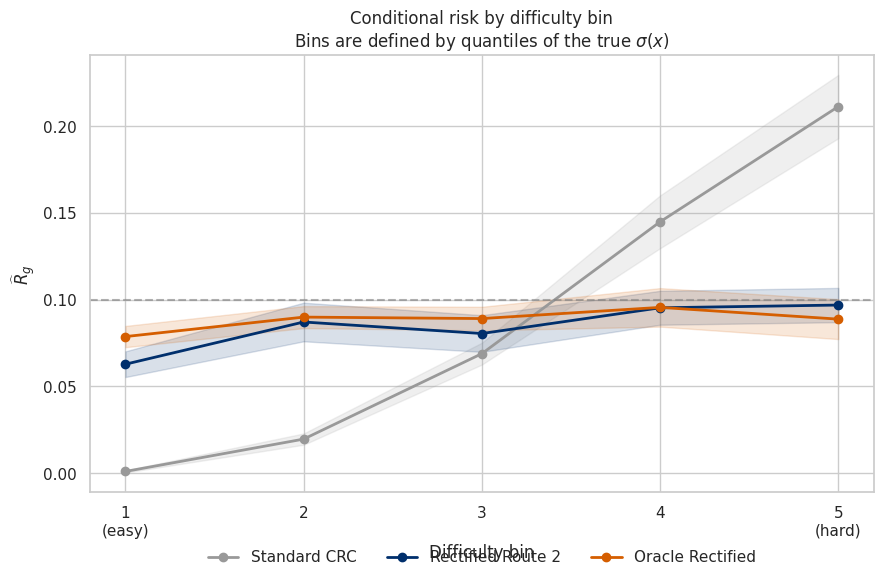

In [191]:
# ============================================================
# Conditional risk by difficulty bin
# ============================================================

df_bins = todos.copy()
df_bins["R_bins"] = df_bins["R_bins"].apply(
    lambda x: x if isinstance(x, list) else x.tolist()
)
df_bins = df_bins.explode("R_bins")
df_bins["difficulty_bin"] = (
    df_bins.groupby(["rodada", "metodo"]).cumcount() + 1
)
df_bins["R_g"] = pd.to_numeric(df_bins["R_bins"])
df_bins["metodo"] = pd.Categorical(df_bins["metodo"], categories=method_order)

df_bins_summary = (
    df_bins
    .groupby(["metodo", "difficulty_bin"], observed=False)["R_g"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
df_bins_summary["se"] = df_bins_summary["std"] / np.sqrt(df_bins_summary["count"])

fig, ax = plt.subplots(figsize=(9, 6))

for method in method_order:
    data_m = df_bins_summary[df_bins_summary["metodo"] == method]

    ax.plot(
        data_m["difficulty_bin"],
        data_m["mean"],
        "o-",
        color=method_colors[method],
        label=method_labels[method],
        linewidth=2,
        markersize=6
    )

    ax.fill_between(
        data_m["difficulty_bin"],
        data_m["mean"] - 2 * data_m["se"],
        data_m["mean"] + 2 * data_m["se"],
        color=method_colors[method],
        alpha=0.15
    )

ax.axhline(config["alpha"], linestyle="--", color="gray", alpha=0.6)

ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(["1\n(easy)", "2", "3", "4", "5\n(hard)"])
ax.set_xlabel("Difficulty bin")
ax.set_ylabel(r"$\widehat R_g$")
ax.set_title(
    "Conditional risk by difficulty bin\n"
    r"Bins are defined by quantiles of the true $\sigma(x)$"
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.savefig("exp_1_conditional_risk_by_difficulty_bin.png", dpi=200, bbox_inches="tight")
plt.show()


In [192]:
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

def smooth_band_for_plot(X, lower, upper, grid_x, smooth_sigma=10.0):
    """
    Smooths the prediction band only for visualization.
    Risk and loss calculations should still use the original bands.

    The smoothing is applied to the band center and width separately.
    """

    order_idx = np.argsort(X)

    X_sorted = X[order_idx]
    lower_sorted = lower[order_idx]
    upper_sorted = upper[order_idx]

    center_sorted = 0.5 * (lower_sorted + upper_sorted)
    width_sorted = upper_sorted - lower_sorted

    center_fun = interp1d(
        X_sorted,
        center_sorted,
        bounds_error=False,
        fill_value="extrapolate"
    )

    width_fun = interp1d(
        X_sorted,
        width_sorted,
        bounds_error=False,
        fill_value="extrapolate"
    )

    center_grid = center_fun(grid_x)
    width_grid = width_fun(grid_x)

    # Stronger visual smoothing
    center_grid = gaussian_filter1d(center_grid, sigma=smooth_sigma)
    width_grid = gaussian_filter1d(width_grid, sigma=smooth_sigma)

    # Prevent numerical negative or too-small widths
    width_grid = np.maximum(width_grid, 1e-8)

    lower_grid = center_grid - 0.5 * width_grid
    upper_grid = center_grid + 0.5 * width_grid

    return lower_grid, upper_grid

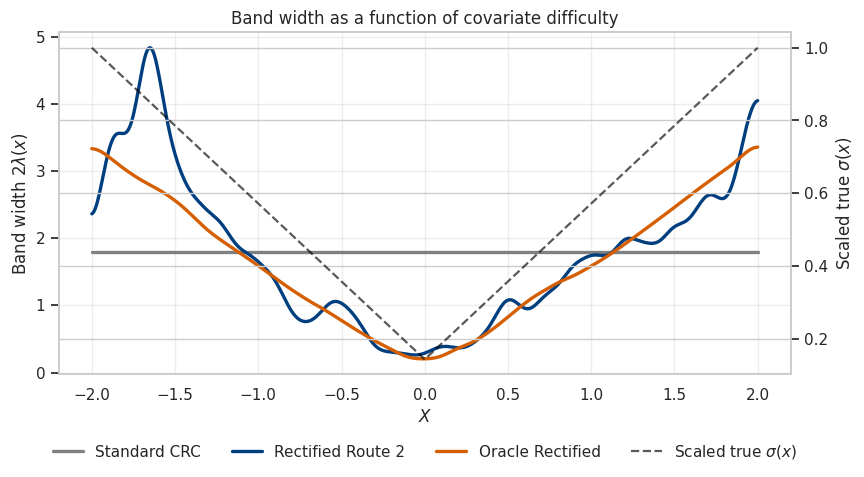

In [193]:
# ============================================================
# Band width as a function of X
# This is often cleaner than plotting full prediction bands
# ============================================================

from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

# ------------------------------------------------------------
# Labels and colors
# ------------------------------------------------------------

method_labels = {
    "crc-padrao": "Standard CRC",
    "rect-route2": "Rectified Route 2",
    "oracle-rect": "Oracle Rectified"
}

method_colors = {
    "crc-padrao": "gray",
    "rect-route2": "#003f7f",
    "oracle-rect": "#d55e00"
}

# Use the same ordering as in the notebook
method_order = ["crc-padrao", "rect-route2", "oracle-rect"]

# ------------------------------------------------------------
# Helper: smooth width only for visualization
# ------------------------------------------------------------

def smooth_width_for_plot(X, width, grid_x, smooth_sigma=10.0):
    """
    Interpolates and smooths band width only for visualization.

    All risk metrics should still be computed using the original,
    unsmoothed widths.
    """
    order_idx = np.argsort(X)

    X_sorted = X[order_idx]
    width_sorted = width[order_idx]

    width_fun = interp1d(
        X_sorted,
        width_sorted,
        bounds_error=False,
        fill_value="extrapolate"
    )

    width_grid = width_fun(grid_x)
    width_grid = gaussian_filter1d(width_grid, sigma=smooth_sigma)

    # Avoid numerical negative widths
    width_grid = np.maximum(width_grid, 1e-8)

    return width_grid


# ============================================================
# Figure: band width by X
# ============================================================

fig, ax = plt.subplots(figsize=(8.8, 5.0))

grid_x = np.linspace(-2, 2, 600)

for method in method_order:

    band_data = bandas_r1[method]

    X = band_data["X"]
    lower = band_data["lower"]
    upper = band_data["upper"]

    width = upper - lower

    width_grid = smooth_width_for_plot(
        X=X,
        width=width,
        grid_x=grid_x,
        smooth_sigma=10.0
    )

    ax.plot(
        grid_x,
        width_grid,
        color=method_colors.get(method, "steelblue"),
        linewidth=2.4,
        label=method_labels.get(method, method)
    )

# True heteroscedastic scale, normalized only for visual comparison
sigma_grid = sigma_true(grid_x)
sigma_scaled = sigma_grid / sigma_grid.max()

ax2 = ax.twinx()

ax2.plot(
    grid_x,
    sigma_scaled,
    color="black",
    linestyle="--",
    linewidth=1.6,
    alpha=0.65,
    label=r"Scaled true $\sigma(x)$"
)

ax.set_xlabel(r"$X$")
ax.set_ylabel(r"Band width $2\lambda(x)$")
ax2.set_ylabel(r"Scaled true $\sigma(x)$")

ax.set_title("Band width as a function of covariate difficulty")

lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    frameon=False,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.16)
)

ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig("exp_1_band_width_by_x.png", dpi=200, bbox_inches="tight")
plt.show()

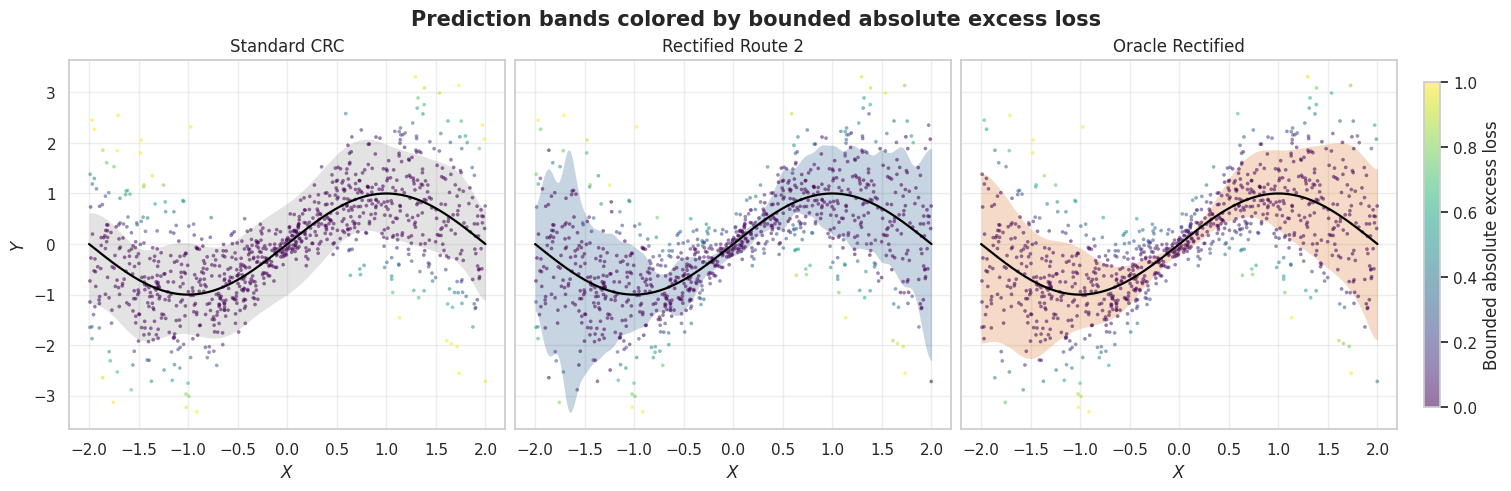

In [195]:
# ============================================================
# Prediction bands colored by bounded absolute excess loss
# Smoothed bands only for visualization
#
# Important: all risks and losses are computed with the original,
# unsmoothed bands. The smoothing below is used only to make the
# shaded bands easier to read in the figure.
# ============================================================

from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d


# ------------------------------------------------------------
# Loss from stored bands
# ------------------------------------------------------------

def bounded_absolute_excess_loss_from_band(band_data, excess_scale=EXCESS_SCALE):
    """
    Computes the bounded absolute excess loss from stored prediction bands.

    The stored bands are assumed to satisfy:

        lower = mu_hat - lambda
        upper = mu_hat + lambda

    Therefore:

        mu_hat = (lower + upper) / 2
        lambda = (upper - lower) / 2
    """

    X = band_data["X"]
    Y = band_data["Y"]
    lower = band_data["lower"]
    upper = band_data["upper"]

    mu_hat = 0.5 * (lower + upper)
    lam = 0.5 * (upper - lower)

    residual = np.abs(Y - mu_hat)

    loss = np.minimum(
        1.0,
        np.maximum(0.0, residual - lam) / excess_scale
    )

    width = upper - lower

    return loss, width, mu_hat, lam


# ------------------------------------------------------------
# Smooth prediction bands for visualization only
# ------------------------------------------------------------

def smooth_band_for_plot(X, lower, upper, grid_x, smooth_sigma=8.0):
    """
    Smooth prediction bands only for visualization.

    The smoothing is applied separately to:
      - the band center: (lower + upper) / 2
      - the band width: upper - lower

    This avoids unstable-looking bands caused by interpolating the lower and
    upper limits separately. Risk and loss calculations should still use the
    original, unsmoothed bands.
    """

    order_idx = np.argsort(X)

    X_sorted = X[order_idx]
    lower_sorted = lower[order_idx]
    upper_sorted = upper[order_idx]

    center_sorted = 0.5 * (lower_sorted + upper_sorted)
    width_sorted = upper_sorted - lower_sorted

    center_fun = interp1d(
        X_sorted,
        center_sorted,
        bounds_error=False,
        fill_value="extrapolate"
    )

    width_fun = interp1d(
        X_sorted,
        width_sorted,
        bounds_error=False,
        fill_value="extrapolate"
    )

    center_grid = center_fun(grid_x)
    width_grid = width_fun(grid_x)

    center_grid = gaussian_filter1d(center_grid, sigma=smooth_sigma)
    width_grid = gaussian_filter1d(width_grid, sigma=smooth_sigma)

    # Avoid numerical negative widths
    width_grid = np.maximum(width_grid, 1e-8)

    lower_grid = center_grid - 0.5 * width_grid
    upper_grid = center_grid + 0.5 * width_grid

    return lower_grid, upper_grid


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4.8),
    sharey=True,
    constrained_layout=True
)

grid_x = np.linspace(-2, 2, 600)
mu_grid = mu_true(grid_x)

scatter_handle = None

for ax, method in zip(axes, method_order):

    band_data = bandas_r1[method]

    X = band_data["X"]
    Y = band_data["Y"]
    lower = band_data["lower"]
    upper = band_data["upper"]

    loss_i, width_i, mu_hat_i, lambda_i = bounded_absolute_excess_loss_from_band(
        band_data,
        excess_scale=EXCESS_SCALE
    )

    lower_grid, upper_grid = smooth_band_for_plot(
        X=X,
        lower=lower,
        upper=upper,
        grid_x=grid_x,
        smooth_sigma=8.0
    )

    ax.fill_between(
        grid_x,
        lower_grid,
        upper_grid,
        color=method_colors.get(method, "steelblue"),
        alpha=0.22,
        linewidth=0
    )

    scatter_handle = ax.scatter(
        X,
        Y,
        c=loss_i,
        s=7,
        alpha=0.55,
        cmap="viridis",
        vmin=0,
        vmax=1,
        edgecolor="none"
    )

    ax.plot(
        grid_x,
        mu_grid,
        color="black",
        linewidth=1.6,
        label=r"True mean $\mu(x)$"
    )

    ax.set_title(method_labels.get(method, method), fontsize=12)
    ax.set_xlabel(r"$X$")
    ax.grid(True, alpha=0.35)

axes[0].set_ylabel(r"$Y$")

colorbar = fig.colorbar(
    scatter_handle,
    ax=axes,
    location="right",
    shrink=0.88,
    pad=0.02
)

colorbar.set_label("Bounded absolute excess loss")

fig.suptitle(
    "Prediction bands colored by bounded absolute excess loss",
    fontsize=15,
    fontweight="bold"
)

plt.savefig(
    "exp_1_prediction_bands_absolute_loss_refined.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

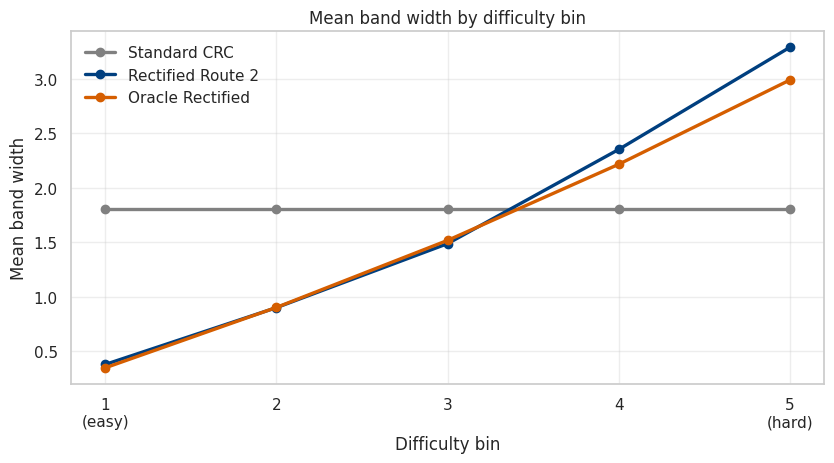

In [194]:
# ============================================================
# Mean band width by difficulty bin
# ============================================================

width_by_bin_records = []

for method in method_order:

    band_data = bandas_r1[method]

    loss_i, width_i, mu_hat_i, lambda_i = bounded_absolute_excess_loss_from_band(
        band_data
    )

    sigma_i = sigma_true(band_data["X"])

    n_bins = 5
    bin_edges = np.quantile(sigma_i, np.linspace(0, 1, n_bins + 1))
    bin_edges[0] -= 1e-9

    difficulty_bins = np.searchsorted(
        bin_edges[1:-1],
        sigma_i,
        side="right"
    )

    for g in range(n_bins):

        idx = difficulty_bins == g

        width_by_bin_records.append({
            "method": method,
            "difficulty_bin": g + 1,
            "mean_width": width_i[idx].mean(),
            "sd_width": width_i[idx].std(ddof=1)
        })

width_by_bin = pd.DataFrame(width_by_bin_records)

fig, ax = plt.subplots(figsize=(8.5, 4.8))

for method in method_order:

    data_m = width_by_bin[width_by_bin["method"] == method]

    ax.plot(
        data_m["difficulty_bin"],
        data_m["mean_width"],
        "o-",
        color=method_colors[method],
        linewidth=2.4,
        markersize=6,
        label=method_labels[method]
    )

ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(["1\n(easy)", "2", "3", "4", "5\n(hard)"])

ax.set_xlabel("Difficulty bin")
ax.set_ylabel("Mean band width")
ax.set_title("Mean band width by difficulty bin")

ax.legend(frameon=False)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig("exp_1_mean_band_width_by_difficulty_bin.png", dpi=200, bbox_inches="tight")
plt.show()


In [196]:
b = bandas_r1["rect-route2"]

loss = bounded_excess_loss(
    np.abs(b["Y"] - 0.5 * (b["lower"] + b["upper"])),
    0.5 * (b["upper"] - b["lower"])
)

np.mean(loss >= 1.0)

np.float64(0.008)

In [197]:
band_route2 = bandas_r1["rect-route2"]

width = band_route2["upper"] - band_route2["lower"]
lambda_vec = width / 2

pd.Series(lambda_vec).describe()

,0
count,1000.000000
mean,0.840000
std,0.656941
min,0.000000
25%,0.300000
50%,0.700000
75%,1.200000
max,4.000000


In [198]:
df_check = pd.DataFrame({
    "X": band_route2["X"],
    "lambda": lambda_vec,
    "width": width
})

df_check["bin_x"] = pd.cut(df_check["X"], bins=np.linspace(-2, 2, 9))

df_check.groupby("bin_x")[["lambda", "width"]].agg(["mean", "min", "max"])

/tmp/ipykernel_465/2769278255.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_check.groupby("bin_x")[["lambda", "width"]].agg(["mean", "min", "max"])


lambda               width          
                  mean  min  max      mean  min  max
bin_x                                               
(-2.0, -1.5]  1.795575  0.5  4.0  3.591150  1.0  8.0
(-1.5, -1.0]  1.168382  0.5  2.4  2.336765  1.0  4.8
(-1.0, -0.5]  0.506107  0.2  1.0  1.012214  0.4  2.0
(-0.5, 0.0]   0.237956  0.0  0.9  0.475912  0.0  1.8
(0.0, 0.5]    0.264800  0.0  1.2  0.529600  0.0  2.4
(0.5, 1.0]    0.573171  0.2  1.0  1.146341  0.4  2.0
(1.0, 1.5]    0.955556  0.4  1.6  1.911111  0.8  3.2
(1.5, 2.0]    1.424771  0.7  2.5  2.849541  1.4  5.0